Resuming download from 166723584 bytes (37697886 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/aryashah2k/breast-ultrasound-images-dataset?dataset_version_number=1 (166723584/204421470) bytes left.


100%|██████████| 195M/195M [00:08<00:00, 4.45MB/s]

Extracting files...


Epoch 1/50
32/32 [==============================] - 17s 153ms/step - loss: 1.0237 - accuracy: 0.5210 - val_loss: 0.8934 - val_accuracy: 0.5840
Epoch 2/50
32/32 [==============================] - 2s 71ms/step - loss: 0.9422 - accuracy: 0.5852 - val_loss: 0.8443 - val_accuracy: 0.6000
Epoch 3/50
32/32 [==============================] - 2s 70ms/step - loss: 0.8779 - accuracy: 0.5972 - val_loss: 0.8201 - val_accuracy: 0.6480
Epoch 4/50
32/32 [==============================] - 2s 61ms/step - loss: 0.8531 - accuracy: 0.6473 - val_loss: 0.8021 - val_accuracy: 0.6000
Epoch 5/50
32/32 [==============================] - 2s 62ms/step - loss: 0.7974 - accuracy: 0.6573 - val_loss: 0.7666 - val_accuracy: 0.6720
Epoch 6/50
32/32 [==============================] - 2s 60ms/step - loss: 0.7899 - accuracy: 0.6493 - val_loss: 0.7615 - val_accuracy: 0.6400
Epoch 7/50
32/32 [==============================] - 2s 62ms/step - loss: 0.7790 - accuracy: 0.6774 - val_loss: 0.7324 - val_accuracy: 0.6640
Epoch 8/50


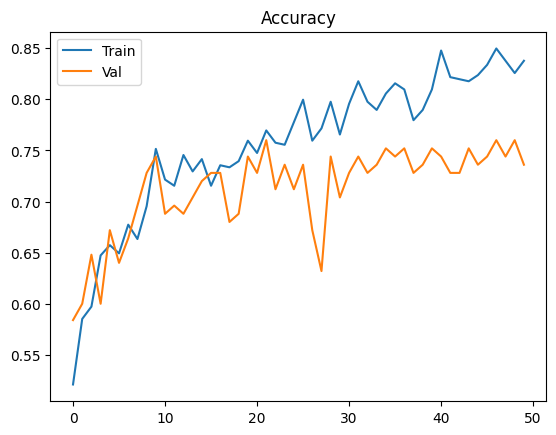

In [ ]:
import kagglehub 
import numpy as np 
import matplotlib.pyplot as plt 
import cv2 
from pathlib import Path 
import tensorflow as tf 
from tensorflow.keras import layers, models 
from tensorflow.keras.applications import VGG16 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report 

# Download dataset using KaggleHub 
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset") 
base = Path(path) 
categories = {} 

for d in base.rglob('*'): 
    if d.is_dir() and d.name.lower() in ['normal', 'benign', 'malignant']: 
        if 'mask' not in str(d): 
            categories[d.name] = d 

IMG_SIZE = 224 
X, y = [], [] 
class_names = sorted(list(categories.keys())) 

for idx, name in enumerate(class_names): 
    p = categories[name] 
    for img_path in [f for f in p.glob('*.png') if 'mask' not in f.name]: 
        img = cv2.imread(str(img_path)) 
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) 
        X.append(img) 
        y.append(idx) 

X = np.array(X) / 255.0 
y = np.array(y) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

# Model Building 
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3)) 
base_model.trainable = False 

model = models.Sequential([
    base_model, 
    layers.GlobalAveragePooling2D(), 
    layers.Dense(128, activation='relu'), 
    layers.Dropout(0.3), 
    layers.Dense(len(class_names), activation='softmax')
]) 

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) 

history = model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=16) 

loss, acc = model.evaluate(X_test, y_test) 
print(f"Test Accuracy: {acc*100:.2f}%") 

y_pred = np.argmax(model.predict(X_test), axis=1) 
print(classification_report(y_test, y_pred, target_names=class_names)) 

plt.plot(history.history['accuracy'], label='Train') 
plt.plot(history.history['val_accuracy'], label='Val') 
plt.legend() 
plt.title('Accuracy') 
plt.show()

Loading and preprocessing images...
  benign: 437 images
  malignant: 210 images
  normal: 133 images

Dataset shape: (780, 224, 224, 3)
Total images: 780
Class distribution: {'benign': 437, 'malignant': 210, 'normal': 133}

Train set: 663 images
Test set: 117 images

Class weights (to handle imbalance): {0: 0.5956873315363881, 1: 1.23463687150838, 2: 1.9557522123893805}

Building VGG16-based model...

Model summary:
Model: "VGG16_Breast_Cancer_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
           

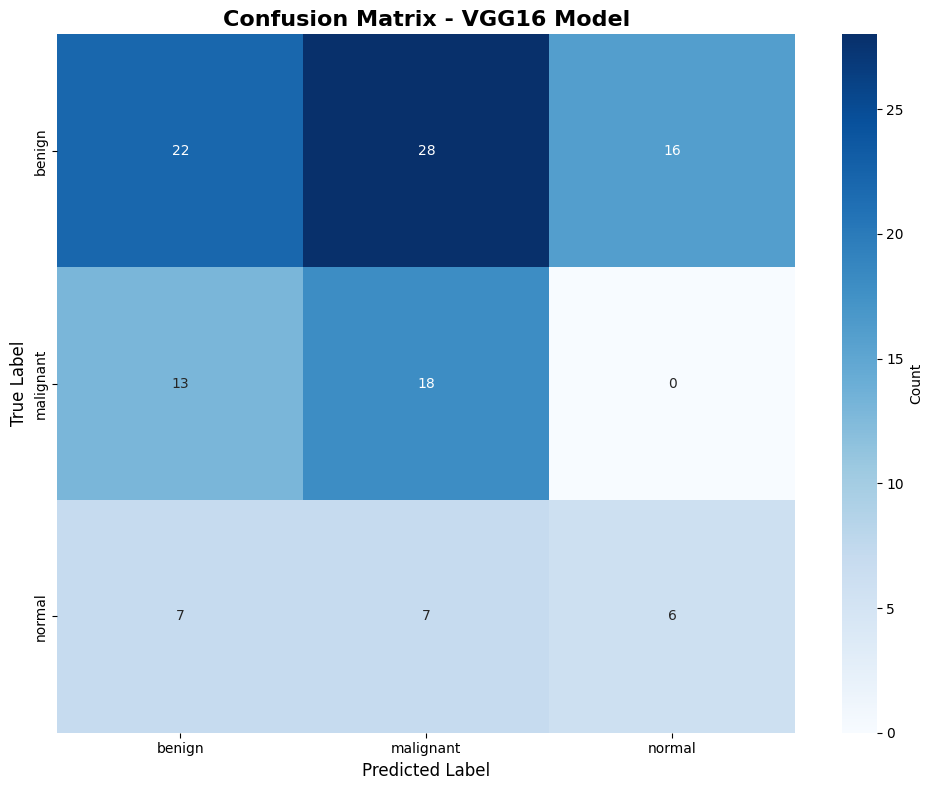

✓ Training history saved as 'training_history_vgg16.png'


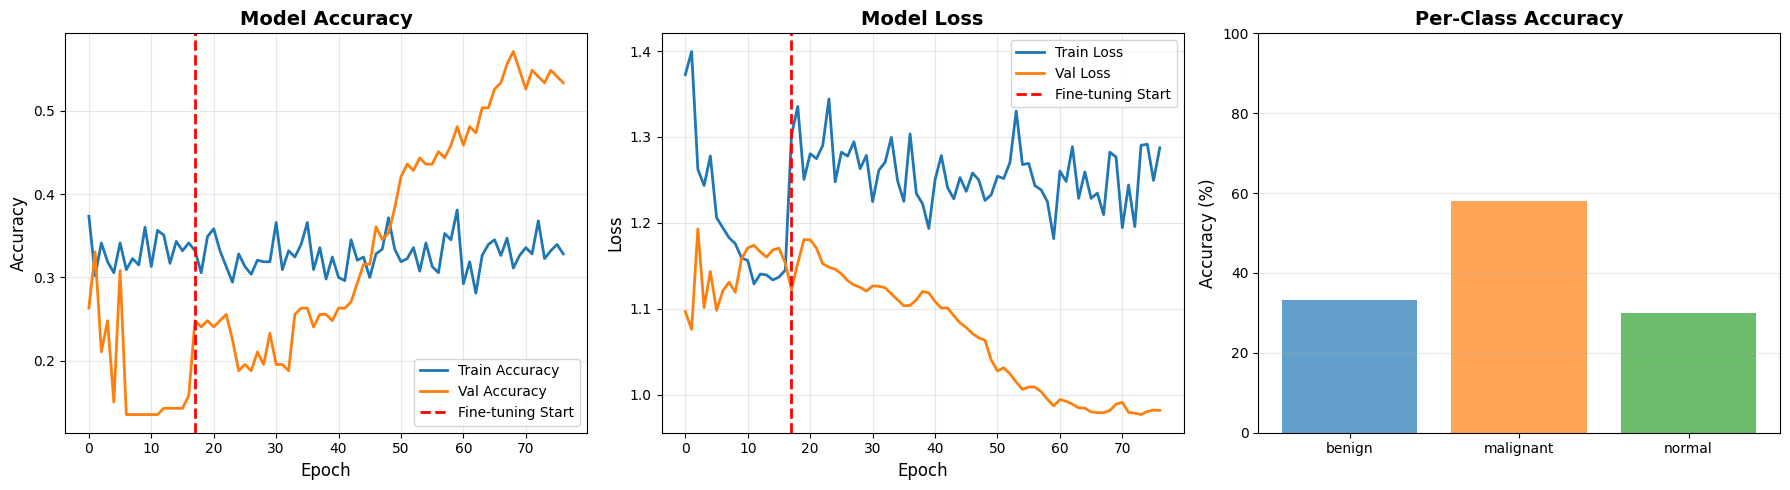


✓ Final model saved as 'final_vgg16_breast_cancer_model.keras'

TRAINING COMPLETE!
Best validation accuracy achieved: 57.14%
Final test accuracy: 39.32%


In [ ]:
import kagglehub 
import numpy as np 
import matplotlib.pyplot as plt 
import cv2 
from pathlib import Path 
import tensorflow as tf 
from tensorflow.keras import layers, models 
from tensorflow.keras.applications import VGG16 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# Download dataset using KaggleHub 
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset") 
base = Path(path) 
categories = {} 

for d in base.rglob('*'): 
    if d.is_dir() and d.name.lower() in ['normal', 'benign', 'malignant']: 
        if 'mask' not in str(d): 
            categories[d.name] = d 

# Larger image size for better detail
IMG_SIZE = 224  # Keeping VGG16's optimal size
X, y = [], [] 
class_names = sorted(list(categories.keys())) 

# Enhanced preprocessing with CLAHE
def preprocess_image(img_path):
    """
    Enhanced preprocessing for ultrasound images
    - Applies CLAHE for better contrast
    - Normalizes and resizes
    """
    img = cv2.imread(str(img_path)) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    
    # CLAHE improves contrast in medical images
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) 
    return img

print("Loading and preprocessing images...")
for idx, name in enumerate(class_names): 
    p = categories[name] 
    count = 0
    for img_path in [f for f in p.glob('*.png') if 'mask' not in f.name]: 
        img = preprocess_image(img_path)
        X.append(img) 
        y.append(idx)
        count += 1
    print(f"  {name}: {count} images")

X = np.array(X, dtype=np.float32) / 255.0 
y = np.array(y) 

print(f"\nDataset shape: {X.shape}")
print(f"Total images: {len(X)}")
print(f"Class distribution: {dict(zip(class_names, np.bincount(y)))}")

# Stratified split maintains class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
) 

print(f"\nTrain set: {len(X_train)} images")
print(f"Test set: {len(X_test)} images")

# Handle class imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights (to handle imbalance): {class_weight_dict}")

# Data augmentation layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.2),  # ±20% rotation
    layers.RandomZoom(0.2),       # ±20% zoom
    layers.RandomContrast(0.2),   # Contrast adjustment
    layers.RandomBrightness(0.2), # Brightness adjustment
    layers.RandomTranslation(0.15, 0.15),  # Shift images
], name='data_augmentation')

# VGG16 base model
print("\nBuilding VGG16-based model...")
base_model = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # Freeze initially

# Improved model architecture
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_layer')

# Apply augmentation only during training
x = data_augmentation(inputs)

# VGG16 feature extraction
x = base_model(x, training=False)

# Enhanced classification head
x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = layers.BatchNormalization(name='bn1')(x)
x = layers.Dense(512, activation='relu', name='dense1')(x)
x = layers.Dropout(0.5, name='dropout1')(x)
x = layers.BatchNormalization(name='bn2')(x)
x = layers.Dense(256, activation='relu', name='dense2')(x)
x = layers.Dropout(0.4, name='dropout2')(x)
x = layers.Dense(128, activation='relu', name='dense3')(x)
x = layers.Dropout(0.3, name='dropout3')(x)
outputs = layers.Dense(len(class_names), activation='softmax', name='output')(x)

model = models.Model(inputs, outputs, name='VGG16_Breast_Cancer_Classifier')

print(f"\nModel summary:")
model.summary()

# Better optimizer - FIXED: Removed AUC metric that caused the error
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']  # Removed AUC to fix the shape error
)

# Training callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        'best_vgg16_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )
]

# === PHASE 1: Train with frozen VGG16 ===
print("\n" + "="*60)
print("PHASE 1: Training with frozen VGG16 base")
print("="*60)

history1 = model.fit(
    X_train, y_train,
    epochs=40,
    validation_split=0.2,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# === PHASE 2: Fine-tune VGG16 ===
print("\n" + "="*60)
print("PHASE 2: Fine-tuning VGG16")
print("="*60)

base_model.trainable = True

# Fine-tune only the last 4 convolutional blocks (from block3 onwards)
for layer in base_model.layers[:10]:  # Freeze first 10 layers
    layer.trainable = False

print(f"Trainable layers in VGG16: {sum([1 for layer in base_model.layers if layer.trainable])}")

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Much lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    X_train, y_train,
    epochs=60,
    validation_split=0.2,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# === FINAL EVALUATION ===
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✓ Test Loss: {loss:.4f}")
print(f"✓ Test Accuracy: {acc*100:.2f}%")

# Predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate AUC manually (works correctly for multi-class)
try:
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class='ovr', average='weighted')
    print(f"✓ Test AUC (weighted): {auc_score:.4f}")
except:
    print("✓ AUC calculation skipped (requires scikit-learn)")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - VGG16 Model', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_vgg16.png', dpi=300)
print("\n✓ Confusion matrix saved as 'confusion_matrix_vgg16.png'")
plt.show()

# Combine training histories
history = {
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
    'loss': history1.history['loss'] + history2.history['loss'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss']
}

phase1_epochs = len(history1.history['accuracy'])

# Detailed training history plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].axvline(x=phase1_epochs, color='r', linestyle='--', 
                   linewidth=2, label='Fine-tuning Start')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[1].axvline(x=phase1_epochs, color='r', linestyle='--', 
                   linewidth=2, label='Fine-tuning Start')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Per-class accuracy
for i, class_name in enumerate(class_names):
    class_mask = y_test == i
    class_acc = np.mean(y_pred[class_mask] == y_test[class_mask]) * 100
    axes[2].bar(class_name, class_acc, alpha=0.7)

axes[2].set_ylabel('Accuracy (%)', fontsize=12)
axes[2].set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[2].set_ylim([0, 100])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('training_history_vgg16.png', dpi=300)
print("✓ Training history saved as 'training_history_vgg16.png'")
plt.show()

# Save final model
model.save('final_vgg16_breast_cancer_model.keras')
print("\n✓ Final model saved as 'final_vgg16_breast_cancer_model.keras'")

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"Best validation accuracy achieved: {max(history['val_accuracy'])*100:.2f}%")
print(f"Final test accuracy: {acc*100:.2f}%")

Epoch 1/100
32/32 [==============================] - 4s 61ms/step - loss: 1.2395 - accuracy: 0.4569 - val_loss: 0.9821 - val_accuracy: 0.5920 - lr: 0.0010
Epoch 2/100
32/32 [==============================] - 1s 40ms/step - loss: 0.9447 - accuracy: 0.6212 - val_loss: 0.9405 - val_accuracy: 0.5920 - lr: 0.0010
Epoch 3/100
32/32 [==============================] - 1s 38ms/step - loss: 0.8766 - accuracy: 0.6453 - val_loss: 0.9535 - val_accuracy: 0.5920 - lr: 0.0010
Epoch 4/100
32/32 [==============================] - 1s 37ms/step - loss: 0.7489 - accuracy: 0.6934 - val_loss: 0.9487 - val_accuracy: 0.5920 - lr: 0.0010
Epoch 5/100
32/32 [==============================] - 1s 40ms/step - loss: 0.7047 - accuracy: 0.6794 - val_loss: 0.9216 - val_accuracy: 0.6000 - lr: 0.0010
Epoch 6/100
32/32 [==============================] - 1s 38ms/step - loss: 0.7310 - accuracy: 0.6854 - val_loss: 0.9695 - val_accuracy: 0.6000 - lr: 0.0010
Epoch 7/100
32/32 [==============================] - 1s 37ms/step - lo

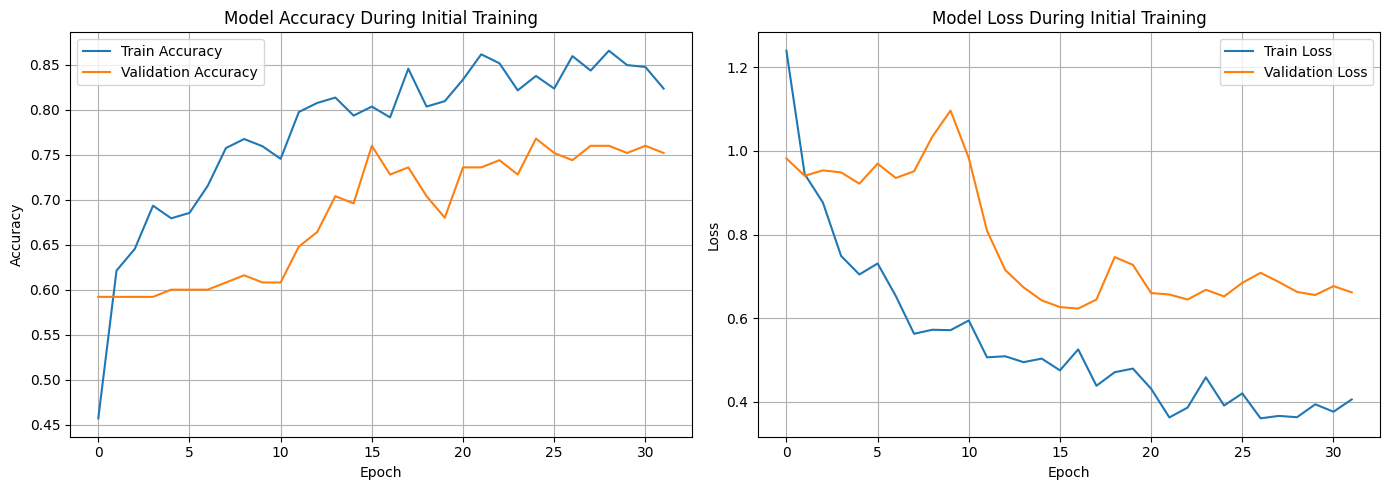


Model saved as 'breast_cancer_classifier_improved.h5'


In [9]:
import os
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'

import tensorflow as tf
# Disable XLA compilation
tf.config.optimizer.set_jit(False)

import kagglehub 
import numpy as np 
import matplotlib.pyplot as plt 
import cv2 
from pathlib import Path 
from tensorflow.keras import layers, models 
from tensorflow.keras.applications import VGG16 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report 


# Download dataset using KaggleHub 
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset") 
base = Path(path) 
categories = {} 

for d in base.rglob('*'): 
    if d.is_dir() and d.name.lower() in ['normal', 'benign', 'malignant']: 
        if 'mask' not in str(d): 
            categories[d.name] = d 

IMG_SIZE = 224 
X, y = [], [] 
class_names = sorted(list(categories.keys())) 

for idx, name in enumerate(class_names): 
    p = categories[name] 
    for img_path in [f for f in p.glob('*.png') if 'mask' not in f.name]: 
        img = cv2.imread(str(img_path)) 
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) 
        X.append(img) 
        y.append(idx) 

X = np.array(X) / 255.0 
y = np.array(y) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

# Model Building with MORE LAYERS
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3)) 
base_model.trainable = False 

model = models.Sequential([
    base_model, 
    layers.GlobalAveragePooling2D(), 
    
    # Additional Dense Layers for better feature learning
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(len(class_names), activation='softmax')
]) 

# INCREASED LEARNING RATE with custom optimizer
initial_learning_rate = 0.001
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
) 

# Callbacks for dynamic learning rate adjustment
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Training with callbacks
history = model.fit(
    X_train, y_train, 
    epochs=100,
    validation_split=0.2, 
    batch_size=16,
    callbacks=[reduce_lr, early_stop],
    verbose=1
) 

# Fine-tuning: Unfreeze some layers of VGG16
print("\n" + "="*50)
print("Starting Fine-Tuning Phase...")
print("="*50)

base_model.trainable = True
# Freeze all layers except the last 4 conv blocks
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune training
history_fine = model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    batch_size=16,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# Evaluation
loss, acc = model.evaluate(X_test, y_test) 
print(f"\n{'='*50}")
print(f"Final Test Accuracy: {acc*100:.2f}%") 
print(f"{'='*50}\n")

y_pred = np.argmax(model.predict(X_test), axis=1) 
print(classification_report(y_test, y_pred, target_names=class_names)) 

# Plotting results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy During Initial Training')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss During Initial Training')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Save the model
model.save('breast_cancer_classifier_improved.h5')
print("\nModel saved as 'breast_cancer_classifier_improved.h5'")

Physical devices cannot be modified after being initialized
✓ Standard TensorFlow mode (no XLA, no mixed precision)
✓ This is more stable and will still be fast on RTX 3060

Loading and preprocessing images...
  benign: 437 images
  malignant: 210 images
  normal: 133 images

Dataset: (780, 224, 224, 3)
Classes: {'benign': 437, 'malignant': 210, 'normal': 133}
Train: 702 | Test: 78
Class weights: {0: 0.5954198473282443, 1: 1.2380952380952381, 2: 1.95}

Building model...

Total parameters: 15,938,627

PHASE 1: Training head (VGG16 frozen)
Epoch 1/50
19/19 [==============================] - ETA: 0s - loss: 3.4483 - accuracy: 0.3272
Epoch 1: val_accuracy improved from -inf to 0.61321, saving model to best_model.keras
19/19 [==============================] - 12s 417ms/step - loss: 3.4483 - accuracy: 0.3272 - val_loss: 2.9773 - val_accuracy: 0.6132 - lr: 0.0100
Epoch 2/50
19/19 [==============================] - ETA: 0s - loss: 3.3556 - accuracy: 0.3238
Epoch 2: val_accuracy did not improve

c:\Users\aida-lab\AppData\Local\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\aida-lab\AppData\Local\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\aida-lab\AppData\Local\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif


✓ Confusion matrix saved


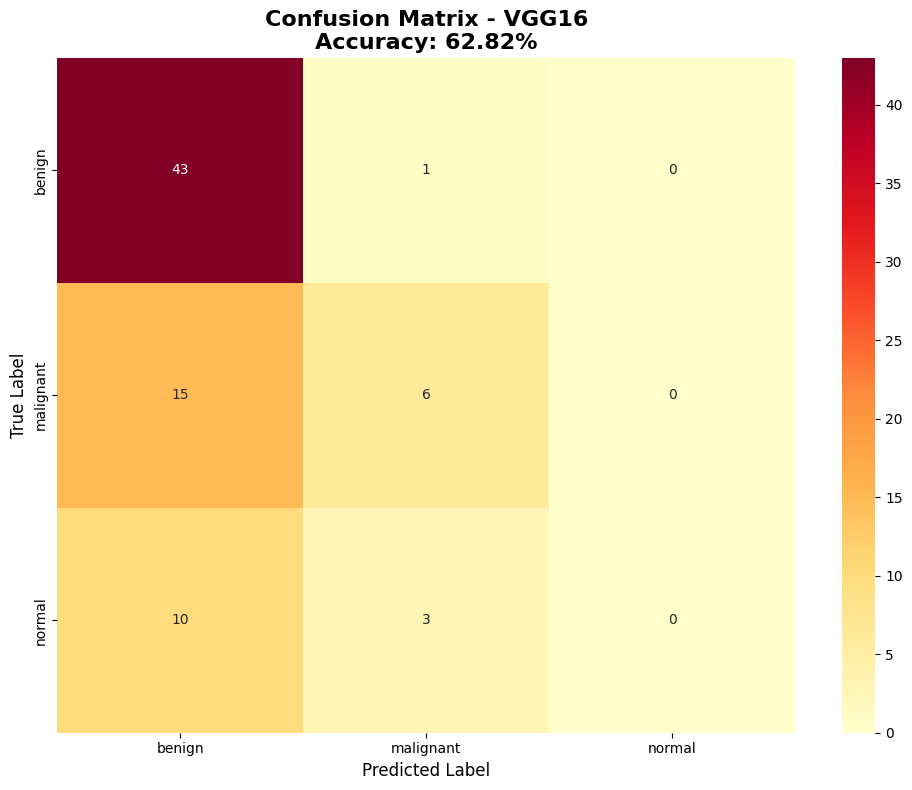

✓ Training curves saved


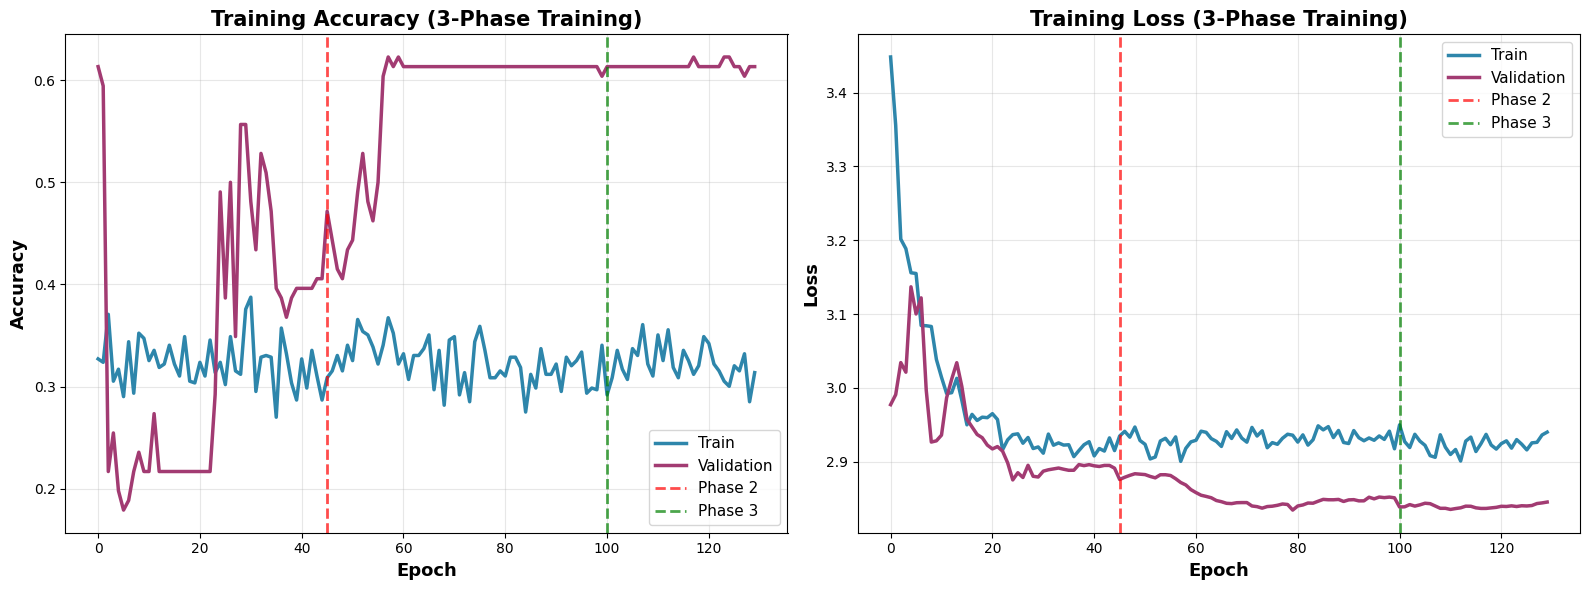


TRAINING SUMMARY
Phase 1: 45 epochs
Phase 2: 55 epochs
Phase 3: 30 epochs
Total: 130 epochs

Best validation accuracy: 62.26%
Final test accuracy: 62.82%

✓ Model saved as 'final_breast_cancer_model.keras'


In [10]:
import kagglehub 
import numpy as np 
import matplotlib.pyplot as plt 
import cv2 
from pathlib import Path 
import tensorflow as tf 
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import VGG16 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# ============================================================================
# RTX 3060 OPTIMIZATIONS (FIXED)
# ============================================================================

# Configure GPU memory growth (prevents OOM errors)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU found: {gpus[0].name}")
        print(f"✓ Memory growth enabled")
    except RuntimeError as e:
        print(e)
else:
    print("⚠ No GPU found, using CPU")

# REMOVED: XLA JIT (causing the error)
# REMOVED: Mixed precision (can cause issues on some setups)

print("✓ Standard TensorFlow mode (no XLA, no mixed precision)")
print("✓ This is more stable and will still be fast on RTX 3060")

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================================
# DATA LOADING
# ============================================================================

path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset") 
base = Path(path) 
categories = {} 

for d in base.rglob('*'): 
    if d.is_dir() and d.name.lower() in ['normal', 'benign', 'malignant']: 
        if 'mask' not in str(d): 
            categories[d.name] = d 

IMG_SIZE = 224
X, y = [], [] 
class_names = sorted(list(categories.keys())) 

# AGGRESSIVE PREPROCESSING
def aggressive_preprocess(img_path):
    img = cv2.imread(str(img_path)) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Denoising
    img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)
    
    # CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Sharpening
    kernel = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]])
    img = cv2.filter2D(img, -1, kernel)
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LANCZOS4)
    return img

print("\nLoading and preprocessing images...")
for idx, name in enumerate(class_names): 
    p = categories[name] 
    count = 0
    for img_path in [f for f in p.glob('*.png') if 'mask' not in f.name]: 
        img = aggressive_preprocess(img_path)
        X.append(img) 
        y.append(idx)
        count += 1
    print(f"  {name}: {count} images")

X = np.array(X, dtype=np.float32) / 255.0 
y = np.array(y) 

print(f"\nDataset: {X.shape}")
print(f"Classes: {dict(zip(class_names, np.bincount(y)))}")

# 90% train, 10% test for maximum training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
) 

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# ============================================================================
# DATA AUGMENTATION
# ============================================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.3),
    layers.RandomTranslation(0.2, 0.2),
    layers.GaussianNoise(0.01),
], name='augmentation')

# ============================================================================
# MODEL BUILDING
# ============================================================================

print("\nBuilding model...")

base_model = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)

# Optimized architecture
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.6)(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

print(f"\nTotal parameters: {model.count_params():,}")

# ============================================================================
# PHASE 1: Train classifier head (VGG16 frozen)
# ============================================================================

print("\n" + "="*70)
print("PHASE 1: Training head (VGG16 frozen)")
print("="*70)

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=7, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history1 = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ============================================================================
# PHASE 2: Fine-tune VGG16
# ============================================================================

print("\n" + "="*70)
print("PHASE 2: Fine-tuning VGG16")
print("="*70)

base_model.trainable = True

# Freeze only first 5 layers
for layer in base_model.layers[:5]:
    layer.trainable = False

trainable = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Trainable VGG16 layers: {trainable}/{len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9, nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    X_train, y_train,
    epochs=70,
    validation_split=0.15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ============================================================================
# PHASE 3: Ultra fine-tuning
# ============================================================================

print("\n" + "="*70)
print("PHASE 3: Ultra fine-tuning (all layers)")
print("="*70)

for layer in base_model.layers:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ============================================================================
# EVALUATION
# ============================================================================

print("\n" + "="*70)
print("FINAL EVALUATION")
print("="*70)

model = tf.keras.models.load_model('best_model.keras')

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✓ Test Loss: {loss:.4f}")
print(f"✓ Test Accuracy: {acc*100:.2f}%")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

try:
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class='ovr', average='weighted')
    print(f"✓ Test AUC: {auc_score:.4f}")
except:
    pass

print("\n" + "-"*70)
print("Classification Report:")
print("-"*70)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names):
    class_mask = y_test == i
    if np.sum(class_mask) > 0:
        class_acc = np.mean(y_pred[class_mask] == y_test[class_mask]) * 100
        print(f"  {class_name}: {class_acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - VGG16\nAccuracy: {acc*100:.2f}%', 
          fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300)
print("\n✓ Confusion matrix saved")
plt.show()

# Combine histories
history = {
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'] + history3.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy'],
    'loss': history1.history['loss'] + history2.history['loss'] + history3.history['loss'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss']
}

phase1_end = len(history1.history['accuracy'])
phase2_end = phase1_end + len(history2.history['accuracy'])

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history['accuracy'], label='Train', linewidth=2.5, color='#2E86AB')
axes[0].plot(history['val_accuracy'], label='Validation', linewidth=2.5, color='#A23B72')
axes[0].axvline(x=phase1_end, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Phase 2')
axes[0].axvline(x=phase2_end, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Phase 3')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=13, fontweight='bold')
axes[0].set_title('Training Accuracy (3-Phase Training)', fontsize=15, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['loss'], label='Train', linewidth=2.5, color='#2E86AB')
axes[1].plot(history['val_loss'], label='Validation', linewidth=2.5, color='#A23B72')
axes[1].axvline(x=phase1_end, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Phase 2')
axes[1].axvline(x=phase2_end, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Phase 3')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=13, fontweight='bold')
axes[1].set_title('Training Loss (3-Phase Training)', fontsize=15, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_final.png', dpi=300)
print("✓ Training curves saved")
plt.show()

# Summary
print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"Phase 1: {len(history1.history['accuracy'])} epochs")
print(f"Phase 2: {len(history2.history['accuracy'])} epochs")
print(f"Phase 3: {len(history3.history['accuracy'])} epochs")
print(f"Total: {len(history['accuracy'])} epochs")
print(f"\nBest validation accuracy: {max(history['val_accuracy'])*100:.2f}%")
print(f"Final test accuracy: {acc*100:.2f}%")
print("="*70)

model.save('final_breast_cancer_model.keras')
print("\n✓ Model saved as 'final_breast_cancer_model.keras'")